<a href="https://colab.research.google.com/github/dhruthirs/adversarial-resilience/blob/main/notebooks/mnist_fgsm_pgd_warmup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adversarial Attack Warm-Up: FGSM on MNIST

**Goal:** train a small CNN, attack it with FGSM, and see how much its accuracy drops.

This is the smallest possible version of the full pipeline you'll scale up for your mini project:
`load model -> attack -> measure accuracy drop`.

Run each cell top to bottom (Shift+Enter). If on Colab, make sure Runtime -> Change runtime type -> GPU is selected.

In [ ]:
eps = 0.2
alpha = 0.02        # increased so PGD can reach the full eps budget
steps = 40          # more iterations = more refined attack

atk_pgd = torchattacks.PGD(model, eps=eps, alpha=alpha, steps=steps)

model.eval()
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images = atk_pgd(images, labels)

    outputs = model(adv_images)
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

pgd_accuracy = 100 * correct / total
print(f'Accuracy UNDER PGD attack (eps={eps}): {pgd_accuracy:.2f}%')
print(f'Attack Success Rate (ASR): {100 - pgd_accuracy:.2f}%')

Accuracy UNDER PGD attack (eps=0.2): 3.99%
Attack Success Rate (ASR): 96.01%


## Step A: Install the attack library

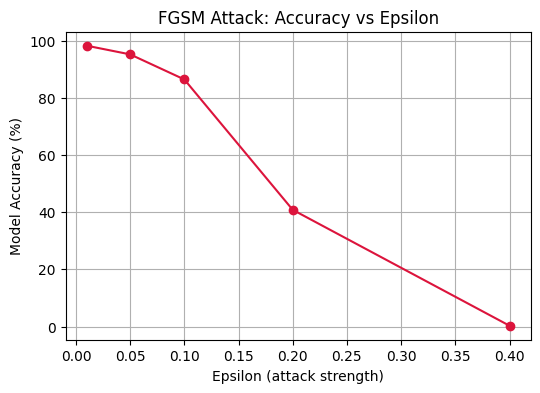

In [ ]:
import matplotlib.pyplot as plt

eps_values = [0.01, 0.05, 0.1, 0.2, 0.4]
accuracies = [98.29, 95.26, 86.48, 40.84, 0.28]  # from your results above

plt.figure(figsize=(6,4))
plt.plot(eps_values, accuracies, marker='o', color='crimson')
plt.xlabel('Epsilon (attack strength)')
plt.ylabel('Model Accuracy (%)')
plt.title('FGSM Attack: Accuracy vs Epsilon')
plt.grid(True)
plt.show()

In [ ]:
!pip install torchattacks -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 6.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.25.1 which is incompatible.
libpysal 4.14.1 requires requests>=2.32.0, but you have requests 2.25.1 which is incompatible.
google-adk 2.3.0 requires requests<3,>=2.32.4, but you have requests 2.25.1 which is incompatible.
pysal 25.7 requires requests>=2.27, but you have reques

## Step B: Imports and device setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torchattacks

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## Step C: Load MNIST (handwritten digits, 28x28 grayscale images)

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])

train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=128, shuffle=False)

print(f'Train samples: {len(train_set)}, Test samples: {len(test_set)}')

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.00MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 732kB/s]


Train samples: 60000, Test samples: 10000


## Step D: Define a small CNN

Nothing fancy — two conv layers, enough to get ~98% accuracy on MNIST in a couple minutes.

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


## Step E: Train it (2 epochs is enough for MNIST to hit ~98%)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 2

model.train()
for epoch in range(EPOCHS):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f'Epoch {epoch+1}/{EPOCHS} - loss: {running_loss/len(train_loader):.4f}')

print('Training done.')

Epoch 1/2 - loss: 0.2397
Epoch 2/2 - loss: 0.0603
Training done.


## Step F: Measure CLEAN accuracy (before any attack)

In [ ]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

clean_acc = evaluate(model, test_loader)
print(f'Clean accuracy (no attack): {clean_acc:.2f}%')

Clean accuracy (no attack): 98.46%


## Step G: Run the FGSM attack

`eps` controls how strong the perturbation is. Bigger eps = more visible change, more likely to fool the model.
Try eps=0.1 first (subtle), then eps=0.3 (stronger) to see the difference.

In [ ]:
eps = 0.2   # <-- change ONLY this number to test different strengths

atk = torchattacks.FGSM(model, eps=eps)

model.eval()
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images = atk(images, labels)

    outputs = model(adv_images)
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

adv_accuracy = 100 * correct / total
print(f'Accuracy UNDER FGSM attack (eps={eps}): {adv_accuracy:.2f}%')
print(f'Attack Success Rate (ASR): {100 - adv_accuracy:.2f}%')
print(f'\nDrop from clean accuracy: {clean_acc:.2f}% -> {adv_accuracy:.2f}%')

Accuracy UNDER FGSM attack (eps=0.2): 39.14%
Attack Success Rate (ASR): 60.86%

Drop from clean accuracy: 98.46% -> 39.14%


## Step H: Visualize — original vs adversarial image

This is the important "aha" moment: the two images should look nearly identical to your eyes, but the model gets fooled on the second one.

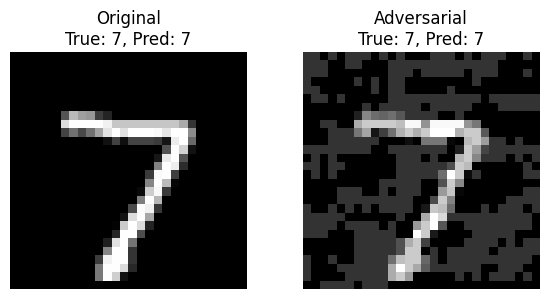

In [ ]:
# grab one batch
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

adv_images = atk(images, labels)

model.eval()
with torch.no_grad():
    clean_pred = model(images).argmax(dim=1)
    adv_pred = model(adv_images).argmax(dim=1)

idx = 0  # change this index to look at different examples

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(images[idx].cpu().squeeze(), cmap='gray')
axes[0].set_title(f'Original\nTrue: {labels[idx].item()}, Pred: {clean_pred[idx].item()}')
axes[0].axis('off')

axes[1].imshow(adv_images[idx].detach().cpu().squeeze(), cmap='gray')
axes[1].set_title(f'Adversarial\nTrue: {labels[idx].item()}, Pred: {adv_pred[idx].item()}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## What to do next

Once this runs end to end and makes sense to your team:
1. Try different `eps` values in Step G (e.g. 0.05, 0.1, 0.3) and note how ASR changes — this becomes your first real experiment/graph.
2. Swap `torchattacks.FGSM` for `torchattacks.PGD` (same syntax) and compare which attack is stronger.
3. Once comfortable, replace MNIST with CIFAR-10 and the SimpleCNN with a real architecture like ResNet18 (`torchvision.models.resnet18`) — this is your actual project's baseline evaluation (Objective 1).
4. Keep this notebook as your template — the pipeline (load model -> attack -> evaluate) is the backbone of everything else you'll build.